<a href="https://colab.research.google.com/github/nguyenduylamdeptrai/Airbnb-Price-Prediction/blob/main/Airbnb_Week1_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Import thư viện xử lý dữ liệu
import pandas as pd
import numpy as np

# Đọc file CSV vào một DataFrame (Bảng dữ liệu)
# Nếu file bạn tải lên có tên khác, hãy sửa lại đoạn 'AB_NYC_2019.csv' cho khớp nhé
df = pd.read_csv('AB_NYC_2019.csv')

# In ra 5 dòng đầu tiên để xem trước
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [2]:
# Trả về một tuple (số_dòng, số_cột)
print("Kích thước dữ liệu:", df.shape)

Kích thước dữ liệu: (48895, 16)


In [3]:
# Hiển thị tên cột, số lượng dữ liệu không bị trống (non-null) và kiểu dữ liệu
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

In [4]:
df.describe()
# Hãy nhìn vào cột price, xem giá trị min (nhỏ nhất) có bằng 0 hay không.
# Nếu có người cho thuê nhà với giá 0$, đó chắc chắn là dữ liệu lỗi (outlier) và chúng ta sẽ phải xóa nó đi ở bước làm sạch!

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,1.373221,7.143982,112.781327
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,1.680442,32.952519,131.622289
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,0.720000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,2.020000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


In [5]:
# Tính tổng số ô trống (NaN) trong từng cột
df.isnull().sum()

,0
id,0
name,16
host_id,0
host_name,21
neighbourhood_group,0
neighbourhood,0
latitude,0
longitude,0
room_type,0
price,0


Xử lý missing value


In [6]:
df.drop(['id', 'host_name', 'last_review'], axis = 1, inplace=True)

df['reviews_per_month'] = df['reviews_per_month'].fillna(0)

# df['host_name'] = df['host_name'].fillna('Unknown')

df['name'] = df['name'].fillna('Unknown')

print("Số lượng dữ liệu thiếu sau khi xử lý:")
print(df.isnull().sum())

Số lượng dữ liệu thiếu sau khi xử lý:
name                              0
host_id                           0
neighbourhood_group               0
neighbourhood                     0
latitude                          0
longitude                         0
room_type                         0
price                             0
minimum_nights                    0
number_of_reviews                 0
reviews_per_month                 0
calculated_host_listings_count    0
availability_365                  0
dtype: int64


Xử lý outliers


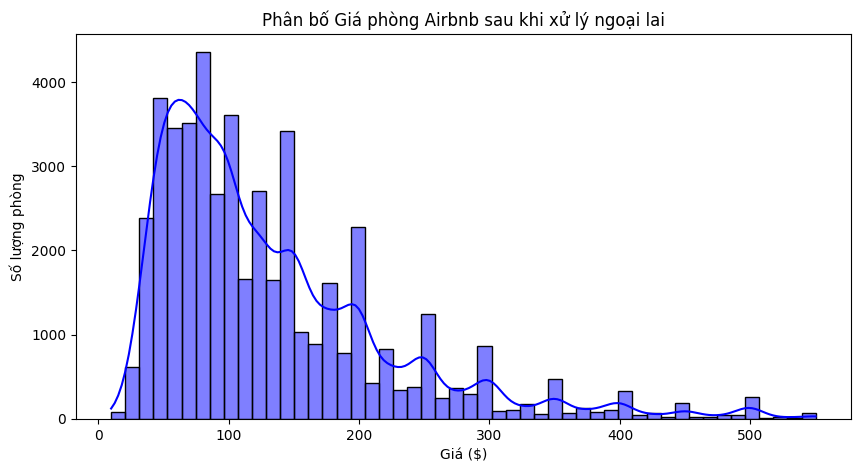

(47909, 13)


In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

df = df[df['price'] > 0]

upper_limit = df['price'].quantile(0.99)
df = df[df['price'] <= upper_limit]

df = df[df['minimum_nights'] < 365]

plt.figure(figsize=(10, 5))
sns.histplot(df['price'], bins=50, kde=True, color='blue')
plt.title('Phân bố Giá phòng Airbnb sau khi xử lý ngoại lai')
plt.xlabel('Giá ($)')
plt.ylabel('Số lượng phòng')
plt.show()

print(df.shape)

/tmp/ipykernel_951/799364872.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='neighbourhood_group', y='price', data=df, palette='Set2')
/tmp/ipykernel_951/799364872.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='room_type', y='price', data=df, palette='viridis', errorbar=None)


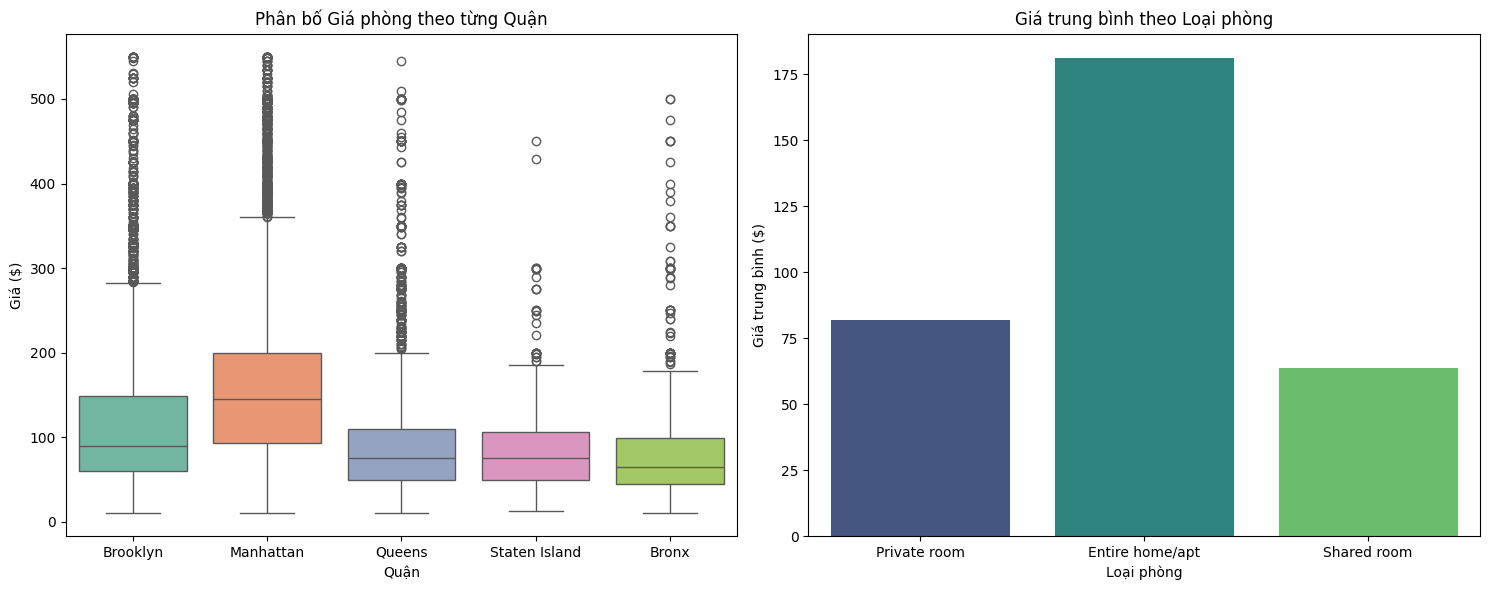

In [10]:
# Tạo cell mới trên Colab và chạy đoạn code này
plt.figure(figsize=(15, 6))

# Biểu đồ 1: So sánh giá giữa các Quận (Neighbourhood Group)
plt.subplot(1, 2, 1)
sns.boxplot(x='neighbourhood_group', y='price', data=df, palette='Set2')
plt.title('Phân bố Giá phòng theo từng Quận')
plt.xlabel('Quận')
plt.ylabel('Giá ($)')

# Biểu đồ 2: So sánh giá trung bình theo Loại phòng (Room Type)
plt.subplot(1, 2, 2)
sns.barplot(x='room_type', y='price', data=df, palette='viridis', errorbar=None)
plt.title('Giá trung bình theo Loại phòng')
plt.xlabel('Loại phòng')
plt.ylabel('Giá trung bình ($)')

plt.tight_layout()
plt.show()

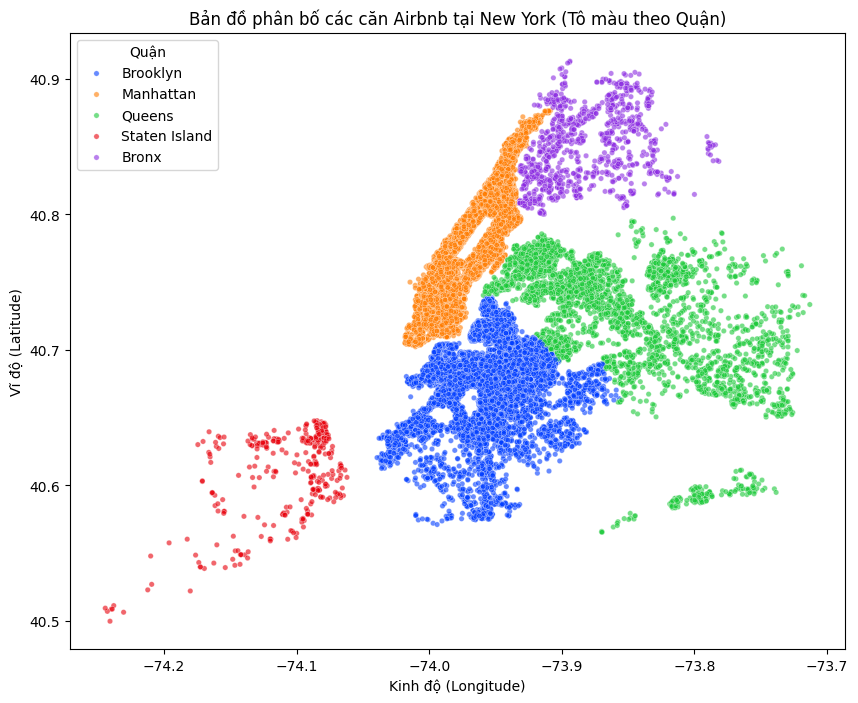

In [11]:
# Tạo cell mới trên Colab và chạy đoạn code này
plt.figure(figsize=(10, 8))

# Dùng scatterplot vẽ tọa độ, tô màu theo Quận (hue)
sns.scatterplot(x='longitude', y='latitude', hue='neighbourhood_group',
                data=df, alpha=0.6, palette='bright', s=15)

plt.title('Bản đồ phân bố các căn Airbnb tại New York (Tô màu theo Quận)')
plt.xlabel('Kinh độ (Longitude)')
plt.ylabel('Vĩ độ (Latitude)')
plt.legend(title='Quận')
plt.show()

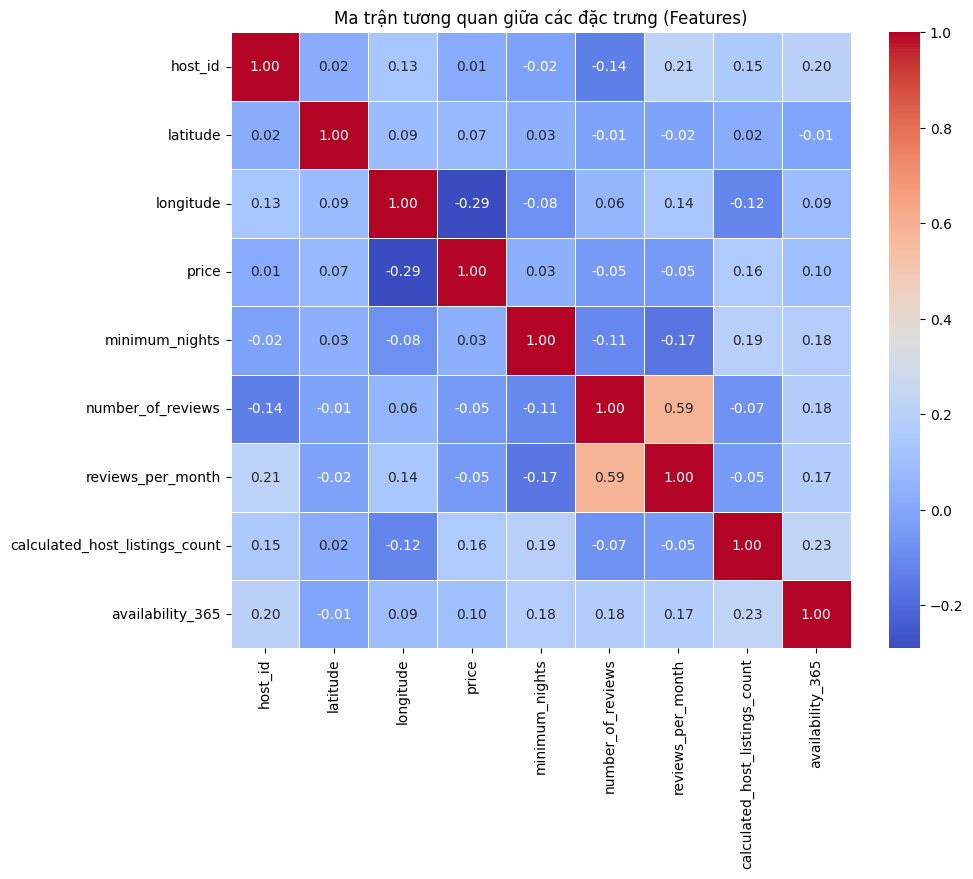

In [12]:
# Tạo cell mới trên Colab và chạy đoạn code này
plt.figure(figsize=(10, 8))

# Lọc ra chỉ các cột chứa dữ liệu số (int, float) thì mới tính tương quan được
numeric_df = df.select_dtypes(include=['int64', 'float64'])

# Tính ma trận tương quan và vẽ heatmap
correlation_matrix = numeric_df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title('Ma trận tương quan giữa các đặc trưng (Features)')
plt.show()

In [13]:
# Xuất dữ liệu đã làm sạch ra file mới (không lưu cột index thừa)
df.to_csv('airbnb_cleaned_data.csv', index=False)

# Tải file này về máy tính của bạn
from google.colab import files
files.download('airbnb_cleaned_data.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>